# Projet de Statistique Appliquée

## Étude comparative de l'efficacité des hôpitaux selon leur statut

Projet d'économétrie appliqué s'appuyant sur les données publiques de la Statistique Annuelle des Établissements (SAE) et d'Hospidiag.

### 1 - Importation des bibliothèques

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

### 2 - Importations des données

Extraction des Outputs et Inputs de 2022, dans un premiers temps on s'intéresse aux services d'Urgence, de Médecine, Chirurgie et obstétrique (MCO), Soins de suite et rééducation (SSR), Psychiatrie, Unité de soins de longue durée (USLD), et séances (séances de dyalise, de chimiothérapie, etc).

In [3]:
SYGEN2022 = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
Data = SYGEN2022[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_DIRSOI','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]

On extrait le statut des différents établissement depuis le fichier FINESS.xlsx obtenu sur le site SAE diffusion.
On crée une distinction entre les hôpitaux publics classiques qui serviront par la suite de référence et les grands hôpitaux publics, les CHU, en ajoutant une catégorie 'CHU' dans la colonne 'Statut'

In [4]:
FINESS = pd.read_excel("finess.xlsx")
FINESS = FINESS.rename(columns={"FINESS":"FI","Statut Juridique":"Statut"})

CHU = pd.read_excel("CHRU.xlsx")
CHU["FINESS"] = CHU["FINESS"].astype(object)

FINESS.loc[FINESS['Raison sociale'].isin(CHU['Raison sociale']), "Statut"] = "CHU"  #Ajout du statut CHU dans la colonne Statut de FINESS
FINESS = FINESS.drop(FINESS.columns[[1,2,4]],axis=1)  #supression des colonnes inutiles

Data = Data.merge(FINESS, on="FI", how="left")

In [5]:
print(Data.shape)
print(SYGEN2022.shape)

(3988, 20)
(3988, 208)


Extraction des données Hospidiag 2022 :

In [6]:
hd2022 = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")

Ajout des output des services d'urgences (nombre de passages) :

In [ ]:
Urg2022 = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
Urg2022 = Urg2022[['FI','PASSU']]
Urg2022 = Urg2022.groupby("FI").sum().reset_index()  # Agrégation des données d'urgences par établissement
Data = Data.merge(Urg2022, on="FI", how="left")

Ajout des entrées au unités de soins longue durée (USLD) :

In [8]:
USLD2022 = pd.read_csv("SAE/2022/USLD_2022r.csv", sep=";", encoding="latin-1")
USLD2022 = USLD2022[['FI','ENT']]
Data = Data.merge(USLD2022, on="FI", how="left")

### 3 - Constructions des variables de la régression

#### 3.1 - Intputs

Total médecins (libéraux et saliariés confondus) : 

In [10]:
Data['EFF_MED'] = Data['EFFSAL_TOT'] + Data['EFFLIB_TOT'].fillna(0)
Data['EFF_MED'].describe()

count    3402.000000
mean       55.711934
std       115.955149
min         0.000000
25%         4.000000
50%        10.000000
75%        54.000000
max      1515.000000
Name: EFF_MED, dtype: float64

Total infirmiers (spécialisés et non-spécialisés) : 

In [15]:
Data['EFF_IDE'] = Data['EFF_INFSANSSPE'] + Data['EFF_INFAVECSPE'].fillna(0)
Data['EFF_IDE'].describe()

count    3600.000000
mean      111.296111
std       234.967032
min         0.000000
25%        11.000000
50%        25.000000
75%        83.000000
max      2090.000000
Name: EFF_IDE, dtype: float64

Total personnel administratif :

In [47]:
Data['EFF_ADMIN'] = Data['EFF_AUTADM'] + Data['EFF_DIRSOI'].fillna(0) + Data['EFF_DIR'].fillna(0)
Data["EFF_ADMIN"].describe()

count    3459.000000
mean       52.078346
std       101.633051
min         0.000000
25%         7.000000
50%        15.000000
75%        43.500000
max       952.000000
Name: EFF_ADMIN, dtype: float64

In [18]:
Data['EFF_DIR'].describe()

count    2682.000000
mean        3.592468
std         4.096995
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        64.000000
Name: EFF_DIR, dtype: float64

NB : la colonne 'EFF_DIRSOI' comptabilisant les effectifs de directeurs de soins par établissements n'a que 1050 lignes renseignées, sa prise en compte fait passer l'effectif moyen en personnel administratif de 62 à 63, l'influence de cette catégorie de personnel peut donc sans doute être considéré comme mineur.

#### 3.2 - Outputs

Total séjours MCO (hospitalisation partielle et complète confondu) :

In [19]:
Data['MCO'] = Data['SEJHP_MCO'] + Data['SEJHC_MCO']
Data['MCO'] = Data['MCO'].fillna(0)
Data['I_MCO'] = (Data['MCO'] > 0).astype(int)

Total séjours en psychiatrie (hospitalisations complètes, venues de jour et venues de nuit) :

In [20]:
Data['PSY'] = Data['SEJ_HTP_TOT'] + Data['VEN_HDJ_TOT'].fillna(0) + Data['VEN_HDN_TOT'].fillna(0)
Data['PSY'].describe()

count      541.000000
mean      7443.051756
std       7648.619662
min          0.000000
25%       1797.000000
50%       5215.000000
75%      10506.000000
max      47168.000000
Name: PSY, dtype: float64

In [21]:
Data['PSY'] = Data['PSY'].fillna(0)
Data['I_PSY'] = (Data['PSY'] > 0).astype(int)

In [22]:
Data["SEANCES"] = Data['SEAN_HEMO_CENTRE'].fillna(0) + Data['SEAN_CHIMIO'] + Data['SEAN_RADIO'].fillna(0)
Data["SEANCES"].describe()

count      795.000000
mean     10883.817610
std      15793.585328
min          0.000000
25%        697.000000
50%       3689.000000
75%      14192.000000
max      81352.000000
Name: SEANCES, dtype: float64

In [24]:
Data['SEANCES'] = Data['SEANCES'].fillna(0)
Data['I_SEANCES'] = (Data['SEANCES'] > 0).astype(int)

In [25]:
Data['PASSU'].describe()

count       693.000000
mean      31217.946609
std       19439.701167
min           0.000000
25%       16727.000000
50%       26546.000000
75%       40563.000000
max      113596.000000
Name: PASSU, dtype: float64

In [26]:
Data['PASSU'] = Data['PASSU'].fillna(0)
Data['I_URG'] = (Data['PASSU'] > 0).astype(int)

In [27]:
Data['PASSU'][Data['PASSU'] > 0]

0       42384.0
1       16727.0
13      22583.0
23      23369.0
24      38727.0
         ...   
3992    18143.0
3993    35983.0
3994    14081.0
3995    31213.0
4052    49595.0
Name: PASSU, Length: 692, dtype: float64

In [28]:
Data['ENT'].describe()

count    592.000000
mean      29.587838
std       20.884803
min        0.000000
25%       17.000000
50%       24.000000
75%       37.000000
max      167.000000
Name: ENT, dtype: float64

In [29]:
Data['ENT'] = Data['ENT'].fillna(0)
Data['I_USLD'] = (Data['ENT'] > 0).astype(int)

In [30]:
Data["SEJHC_SSR"].describe()

count    1847.000000
mean      472.886302
std       379.944830
min         0.000000
25%       220.000000
50%       377.000000
75%       632.500000
max      2755.000000
Name: SEJHC_SSR, dtype: float64

In [31]:
Data['SEJHC_SSR'] = Data['SEJHC_SSR'].fillna(0)
Data['I_SSR'] = (Data['SEJHC_SSR'] > 0).astype(int)

#### 3.3 - Passage au log

Passage des variables d'intérêt en log (En ajoutant +1 pour éviter des valeurs négatives/-infini) :

In [48]:
Data["lURG"] = np.log(Data["PASSU"]+1)
Data["lMCO_HC"] = np.log(SYGEN2022["SEJHC_MCO"].fillna(0)+1)
Data["lMCO_HP"] = np.log(SYGEN2022["SEJHP_MCO"].fillna(0)+1)
Data["lPSY"] = np.log(Data["PSY"]+1)
Data["lSSR"] = np.log(Data["SEJHC_SSR"]+1)
Data["lSEANCES"] = np.log(Data["SEANCES"]+1)
Data['lUSLD'] = np.log(Data['ENT']+1)

Data["lMED"] = np.log(Data["EFF_MED"]+1)
Data["lIDE"] = np.log(Data["EFF_IDE"]+1)
Data["lAID"] = np.log(Data["EFF_AID"]+1)
Data["lADMIN"] = np.log(Data["EFF_ADMIN"]+1)

#### 3.4 - Ajout de variables de contrôles

On construit deux variables de contrôle : Statut_PNL (resp. Statut_PL) vaut 1 si l'établissement est privé non lucratif (resp. privé lucratif) 

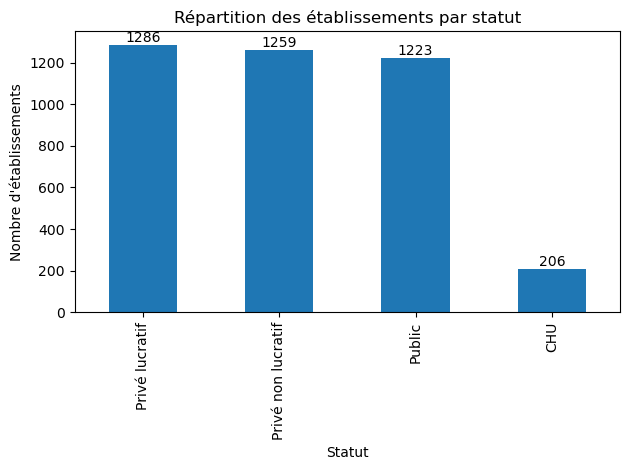

In [33]:
counts = FINESS["Statut"].value_counts()
ax = counts.plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Répartition des établissements par statut")
plt.xlabel("Statut")
plt.ylabel("Nombre d'établissements")

plt.tight_layout()
plt.show()

In [34]:
dummies = pd.get_dummies(Data["Statut"], prefix="Statut")

Data["Statut_PNL"] = dummies["Statut_Privé non lucratif"]
Data["Statut_PL"]  = dummies["Statut_Privé lucratif"]
Data["Statut_CHU"] = dummies["Statut_CHU"]

Data["Statut_PNL"] = Data["Statut_PNL"].astype(int)
Data["Statut_PL"]  = Data["Statut_PL"].astype(int)
Data["Statut_CHU"] = Data["Statut_CHU"].astype(int)

Catégorisation des variables :

In [62]:
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]
outputs = ["lURG", "lMCO_HP","lMCO_HC", "lSSR", "lPSY","lSEANCES", "lUSLD"]
controles_statut = ["Statut_PNL", "Statut_PL","Statut_CHU"] 
controles_services = ["I_PSY", "I_SSR", "I_URG", "I_USLD","I_SEANCES", "I_MCO"]
controles_autres= ["lduree_MCO"]
controles_hospidiag = ["A9_imp"]
interactions_statut = [f"{var}_PNL" for var in outputs] + [f"{var}_PL" for var in outputs] + [f"{var}_CHU" for var in outputs]

Ajout de variables d'outputs liées aux différentes catégories d'établissement contrôlées ("termes d'interaction") :

In [36]:
for var in outputs:
    Data[f"{var}_PNL"] = Data[var] * Data["Statut_PNL"]
    Data[f"{var}_PL"]  = Data[var] * Data["Statut_PL"]
    Data[f"{var}_CHU"]  = Data[var] * Data["Statut_CHU"]

Pour mieux mesurer le gain d'efficacité lié à la réduction de la durée des séjours, on construit la variable "lduree_MCO" contient la durée moyenne d'un séjour en hospitalisation complète en log.

In [37]:
Data["duree_MCO"] = SYGEN2022['JOU_MCO']/SYGEN2022['SEJHC_MCO']
Data["duree_MCO"] = Data["duree_MCO"].fillna(0)
Data["lduree_MCO"] = np.log(Data["duree_MCO"]+1)

On souhaite également contrôler pour la gravité des cas, pour cela on utilise l'indicateur A9 d'Hospidiag

Un graphique assez éloquent sur la répartition des médecins (en log) selon le statut de l'établissement de santé :

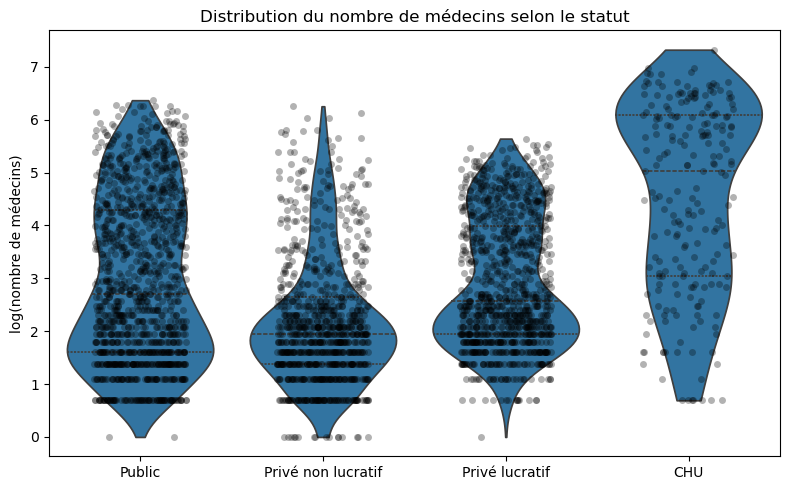

In [38]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=Data,
    x="Statut",
    y="lMED",
    inner="quartile",
    cut=0,
    density_norm="width"
)
sns.stripplot(
    data=Data,
    x="Statut",
    y="lMED",
    color='black',
    jitter=0.25,
    alpha=0.3
)


plt.title("Distribution du nombre de médecins selon le statut")
plt.ylabel("log(nombre de médecins)")
plt.xlabel("")
plt.tight_layout()
plt.show()

Ajout des valeurs imputées de l'indicateur de gravité A9 d'hospidiag : 

In [73]:
A9_imputed = pd.read_csv("A9_imputed.csv", sep=",", decimal = ".", encoding="utf-8")
A9_imputed

,FI,A9_imp
0,010000024,11.360
1,010000032,18.320
2,010000065,54.820
3,010000081,13.276
4,010000099,59.410
...,...,...
3983,980500763,0.000
3984,980500920,12.868
3985,980501159,13.474
3986,980501258,13.474


In [74]:
Data = Data.merge(A9_imputed, on="FI", how="left")

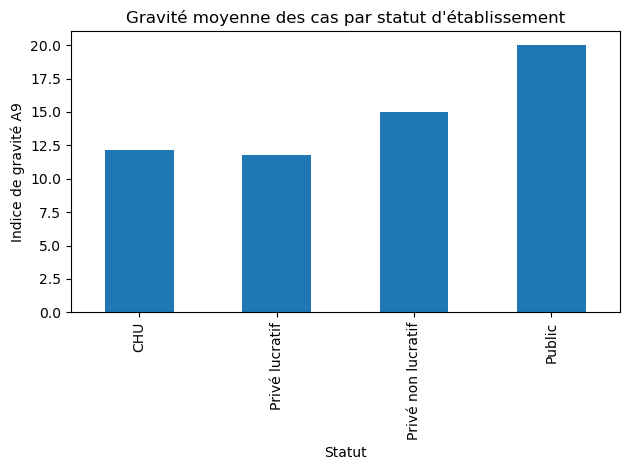

In [75]:
mean_grav = Data.groupby("Statut")["A9_imp"].mean()

mean_grav.plot(kind="bar")

plt.title("Gravité moyenne des cas par statut d'établissement")
plt.ylabel("Indice de gravité A9")
plt.xlabel("Statut")

plt.tight_layout()
plt.show()

### 4 - Première approche : régression linéaire en contrôlant pour le statut

#### 4.1 - Estimation des coefficients de la demande conditionnelle

Préparation des données à la régression : 

In [96]:
X_vars = (outputs + controles_statut + controles_services + controles_autres + interactions_statut + controles_hospidiag)

Data_clean = Data[inputs + X_vars].copy()

# Conversion forcée en numérique
Data_clean = Data_clean.apply(pd.to_numeric, errors="coerce")

# Suppression des lignes inexploitables
Data_clean = Data_clean.dropna()

Data_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,...,lSEANCES_PL,lUSLD_PL,lURG_CHU,lMCO_HP_CHU,lMCO_HC_CHU,lSSR_CHU,lPSY_CHU,lSEANCES_CHU,lUSLD_CHU,A9_imp
count,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,...,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000,2975.000000
mean,3.013056,3.808056,3.657175,3.141120,2.289460,2.461271,2.927563,3.309607,1.405033,1.939547,...,0.515906,0.014254,0.352749,0.160152,0.176132,0.209979,0.135958,0.342742,0.053383,16.304179
std,1.467972,1.381843,1.308363,1.311371,4.258706,3.838782,3.920205,3.029377,3.165077,3.616663,...,2.004795,0.209543,1.906183,1.160271,1.194480,1.127340,1.030412,1.763942,0.440665,12.581114
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.791759,2.772589,2.772589,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.366000
50%,2.639057,3.496508,3.526361,2.890372,0.000000,0.000000,0.000000,5.043425,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.110000
75%,4.189655,4.731793,4.465908,3.988984,0.000000,6.951976,7.166266,6.109248,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.536000
max,7.323831,7.645398,7.515889,6.859615,11.640412,10.914525,11.235352,7.921536,10.761492,11.306553,...,11.029699,3.931826,11.640412,10.552918,10.833129,7.819636,10.328723,11.273551,5.123964,94.740000


On va donc réaliser une estimation à partir de 2975 observations sur l'année 2022 (sur les 3988 observations disponibles), soit une utilisation 75%.

Estimation des coefficients : On régresse les inputs (médecins, infirmiers, aides soignantes, personnel adminisitratif) sur les outputs et les contrôles

In [97]:
results = {}
dict_diff = {}

In [98]:
for inp in inputs:
    y = Data_clean[inp]

    X = Data_clean[X_vars]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results[inp] = model

In [99]:
for inp, model in results.items():
    for statut in ["PNL", "PL", "CHU"]:
        coef_name = f"Statut_{statut}"

        if coef_name in model.params.index:
            coef = model.params[coef_name]
            pct = (np.exp(coef) - 1) * 100
            dict_diff[(inp, statut)] = pct

#### 4.2 - Résultats

In [100]:
dict_diff

{('lMED', 'PNL'): 26.91829478006249,
 ('lMED', 'PL'): 87.57160445422392,
 ('lMED', 'CHU'): 88.23547673763814,
 ('lIDE', 'PNL'): -3.093727730413176,
 ('lIDE', 'PL'): 1.1327578167431573,
 ('lIDE', 'CHU'): 167.09600047366692,
 ('lAID', 'PNL'): -40.60078819475581,
 ('lAID', 'PL'): -39.499105449641,
 ('lAID', 'CHU'): 129.41641398019627,
 ('lADMIN', 'PNL'): 40.656876766689074,
 ('lADMIN', 'PL'): 25.279253923133638,
 ('lADMIN', 'CHU'): 68.1171993488967}

|    |    Privé Lucratif     |   Privé non lucratif    |    CHU   |
|:----------|------------:|-------------:|-------------:|
| Personnel administratif    |      +25% |        +41% |    +68%     |
| Aides-soigant.e.s      |      -39% |     -41%  |      +129%   |
| Infirmièr.e.s      |      +1% |       -3% |    +167%      |
| Médecins      |      +88% |     +27%    |       +88%  |

Tableau regroupant les différences d'emploi des différentes catégories de personnel à niveau de production égal selon la nature de l'etablissement (privé non lucratif,privé lucratif ou CHU) en prenant comme référence les hopitaux publics petits ou moyens (non CHU).

Contrôles : présence de service d'urgence, de MCO, de psychiatrie, de SSR, d'USLD, et de séances ; durée moyenne de séjour en MCO, indice de gravité A9 d'hospidiag

Contrôles à rajouter : indice de recherche/enseignement (hospidiag)

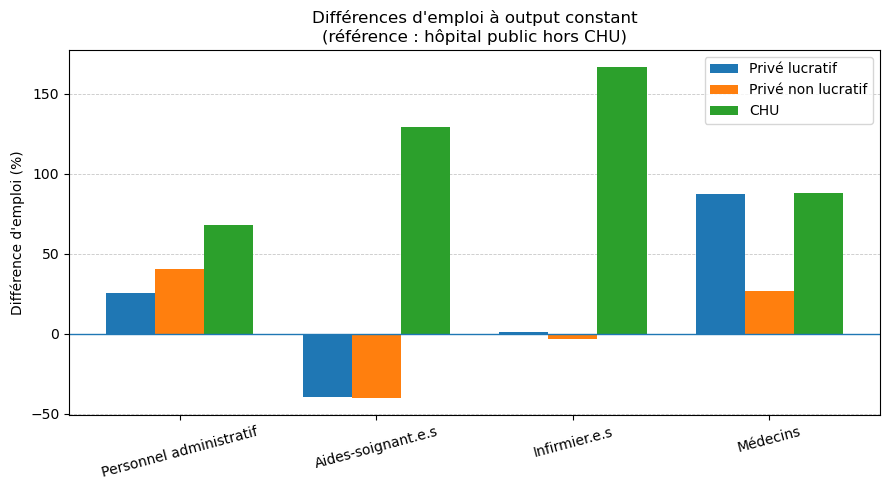

In [101]:
# Passage du dictionnaire à un DataFrame
df = pd.Series(dict_diff).unstack()

# On garde l'ordre souhaité
df = df.loc[["lADMIN", "lAID", "lIDE", "lMED"], ["PL", "PNL", "CHU"]]

# Renommage lisible
df.index = [
    "Personnel administratif",
    "Aides-soignant.e.s",
    "Infirmier.e.s",
    "Médecins"
]

df.columns = [
    "Privé lucratif",
    "Privé non lucratif",
    "CHU"
]

# Paramètres du graphique
x = np.arange(len(df.index))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.yaxis.grid(True,linestyle="--",linewidth=0.6,alpha=0.7)
ax.set_axisbelow(True)

ax.bar(x - width, df["Privé lucratif"], width, label="Privé lucratif")
ax.bar(x, df["Privé non lucratif"], width, label="Privé non lucratif")
ax.bar(x + width, df["CHU"], width, label="CHU")



# Mise en forme
ax.set_ylabel("Différence d'emploi (%)")
ax.set_title(
    "Différences d'emploi à output constant\n"
    "(référence : hôpital public hors CHU)"
)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=15)
ax.legend()

ax.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

Evaluation des régression : R²

In [103]:
for inp, model in results.items():
    print(f"{inp} : R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f}")

lMED : R² = 0.796 | R² ajusté = 0.793
lIDE : R² = 0.784 | R² ajusté = 0.781
lAID : R² = 0.708 | R² ajusté = 0.704
lADMIN : R² = 0.729 | R² ajusté = 0.726


Concernant l'influence mesurée de la durée moyenne des séjours :

In [102]:
for inp, model in results.items():
    print(f"\n{inp}")
    print(model.params["lduree_MCO"])


lMED
-0.027805308877554467

lIDE
-0.0388971303758059

lAID
-0.01590386294779236

lADMIN
0.013028882130558361


Coefficients négatifs ? Très surprenant 

Effet de l'ambulatoire sur les différentes catégories de personnel :

In [104]:
for inp, model in results.items():
    print(f"{inp} : Hospitalisation complète : {model.params["lMCO_HC"]} | Hospitalisation partielle : {model.params["lMCO_HP"]}")

lMED : Hospitalisation complète : -0.0033906676808178006 | Hospitalisation partielle : 0.014750493540085348
lIDE : Hospitalisation complète : 0.012311388346630491 | Hospitalisation partielle : -0.003553894216978477
lAID : Hospitalisation complète : -0.007420288991418144 | Hospitalisation partielle : 0.016462262705123368
lADMIN : Hospitalisation complète : -0.014047998156445338 | Hospitalisation partielle : 0.012730647298286086


Résultats complets des régressions :

In [87]:
results["lMED"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lMED   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     392.5
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:32:42   Log-Likelihood:                -2998.2
No. Observations:                2975   AIC:                             6076.
Df Residuals:                    2935   BIC:                             6316.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.9003      0.059     32.208      0.000       1.785       2.016
lURG             0.4658      0.061      7.643      0.000       0.346       0.585
lMCO_HP          0.0148      0.010      1.414      0.157      -0.006       0.035
lMCO_HC         -0.0034      0.014     -0.246      0.806      -0.030       0.024
lSSR             0.2789      0.030      9.315      0.000       0.220       0.338
lPSY             0.3710      0.029     12.581      0.000       0.313       0.429
lSEANCES         0.1253      0.018      6.991      0.000       0.090       0.160
lUSLD            0.0261      0.043      0.601      0.548      -0.059       0.111
Statut_PNL       0.2384      0.078      3.040      0.002       0.085       0.392
Statut_PL        0.6290      0.081      7.740      0.000       0.470       0.788
Statut_CHU       0.6325      0.158      4.008      0.000       0.323       0.942
I_PSY           -2.0962      0.246     -8.510      0.000      -2.579      -1.613
I_SSR           -1.5329      0.175     -8.759      0.000      -1.876      -1.190
I_URG           -3.5841      0.574     -6.248      0.000      -4.708      -2.460
I_USLD          -0.2618      0.144     -1.815      0.070      -0.544       0.021
I_SEANCES       -0.4681      0.125     -3.744      0.000      -0.713      -0.223
I_MCO            1.1626      0.041     28.188      0.000       1.082       1.243
lduree_MCO      -0.0278      0.029     -0.961      0.337      -0.085       0.029
lURG_PNL        -0.0100      0.014     -0.726      0.468      -0.037       0.017
lMCO_HP_PNL     -0.0137      0.018     -0.754      0.451      -0.049       0.022
lMCO_HC_PNL      0.0239      0.018      1.347      0.178      -0.011       0.059
lSSR_PNL        -0.0064      0.013     -0.504      0.614      -0.031       0.018
lPSY_PNL        -0.0087      0.012     -0.694      0.488      -0.033       0.016
lSEANCES_PNL     0.0492      0.016      3.012      0.003       0.017       0.081
lUSLD_PNL        0.0037      0.032      0.113      0.910      -0.060       0.067
lURG_PL         -0.0452      0.010     -4.350      0.000      -0.066      -0.025
lMCO_HP_PL       0.0037      0.014      0.269      0.788      -0.023       0.030
lMCO_HC_PL      -0.0089      0.013     -0.661      0.508      -0.035       0.018
lSSR_PL         -0.0511      0.012     -4.110      0.000      -0.075      -0.027
lPSY_PL         -0.0892      0.011     -7.978      0.000      -0.111      -0.067
lSEANCES_PL      0.0080      0.014      0.560      0.575      -0.020       0.036
lUSLD_PL        -0.0073      0.044     -0.166      0.868      -0.093       0.078
lURG_CHU         0.0021      0.019      0.111      0.912      -0.035       0.039
lMCO_HP_CHU      0.0198      0.026      0.755      0.450      -0.032       0.071
lMCO_HC_CHU     -0.0119      0.028     -0.430      0.667      -0.066       0.042
lSSR_

In [88]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     297.5
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:32:43   Log-Likelihood:                -2906.4
No. Observations:                2975   AIC:                             5893.
Df Residuals:                    2935   BIC:                             6133.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.0323      0.058     52.398      0.000       2.919       3.146
lURG             0.4376      0.066      6.667      0.000       0.309       0.566
lMCO_HP         -0.0036      0.010     -0.350      0.726      -0.023       0.016
lMCO_HC          0.0123      0.013      0.935      0.350      -0.013       0.038
lSSR             0.2872      0.029      9.805      0.000       0.230       0.345
lPSY             0.4524      0.032     14.076      0.000       0.389       0.515
lSEANCES         0.1473      0.020      7.335      0.000       0.108       0.187
lUSLD            0.1507      0.040      3.733      0.000       0.072       0.230
Statut_PNL      -0.0314      0.082     -0.385      0.700      -0.191       0.129
Statut_PL        0.0113      0.077      0.146      0.884      -0.140       0.163
Statut_CHU       0.9824      0.156      6.310      0.000       0.677       1.288
I_PSY           -2.3846      0.269     -8.857      0.000      -2.912      -1.857
I_SSR           -1.6171      0.169     -9.572      0.000      -1.948      -1.286
I_URG           -3.3253      0.609     -5.456      0.000      -4.520      -2.131
I_USLD          -0.4192      0.135     -3.117      0.002      -0.683      -0.156
I_SEANCES       -0.6682      0.130     -5.154      0.000      -0.922      -0.414
I_MCO            0.6932      0.036     19.303      0.000       0.623       0.764
lduree_MCO      -0.0389      0.026     -1.473      0.141      -0.091       0.013
lURG_PNL         0.0044      0.014      0.324      0.746      -0.022       0.031
lMCO_HP_PNL     -0.0150      0.018     -0.854      0.393      -0.049       0.019
lMCO_HC_PNL      0.0239      0.017      1.421      0.155      -0.009       0.057
lSSR_PNL         0.0163      0.013      1.245      0.213      -0.009       0.042
lPSY_PNL         0.0054      0.015      0.354      0.723      -0.025       0.036
lSEANCES_PNL     0.0387      0.018      2.153      0.031       0.003       0.074
lUSLD_PNL       -0.0087      0.025     -0.342      0.732      -0.058       0.041
lURG_PL         -0.0344      0.012     -2.956      0.003      -0.057      -0.012
lMCO_HP_PL       0.0154      0.012      1.250      0.211      -0.009       0.040
lMCO_HC_PL      -0.0137      0.012     -1.123      0.261      -0.038       0.010
lSSR_PL         -0.0172      0.012     -1.491      0.136      -0.040       0.005
lPSY_PL         -0.0903      0.011     -8.215      0.000      -0.112      -0.069
lSEANCES_PL      0.0193      0.016      1.207      0.227      -0.012       0.051
lUSLD_PL        -0.0252      0.049     -0.518      0.605      -0.120       0.070
lURG_CHU        -0.0104      0.019     -0.538      0.591      -0.048       0.027
lMCO_HP_CHU      0.0005      0.026      0.019      0.985      -0.050       0.051
lMCO_HC_CHU      0.0033      0.027      0.126      0.900      -0.049       0.055
lSSR_

In [89]:
results["lAID"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lAID   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     252.0
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        18:32:45   Log-Likelihood:                -3188.4
No. Observations:                2975   AIC:                             6457.
Df Residuals:                    2935   BIC:                             6697.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.8754      0.061     47.481      0.000       2.757       2.994
lURG             0.4925      0.060      8.182      0.000       0.374       0.610
lMCO_HP          0.0165      0.010      1.613      0.107      -0.004       0.036
lMCO_HC         -0.0074      0.014     -0.536      0.592      -0.035       0.020
lSSR             0.3301      0.031     10.782      0.000       0.270       0.390
lPSY             0.2827      0.034      8.434      0.000       0.217       0.348
lSEANCES         0.1286      0.019      6.814      0.000       0.092       0.166
lUSLD            0.1545      0.039      3.973      0.000       0.078       0.231
Statut_PNL      -0.5209      0.088     -5.941      0.000      -0.693      -0.349
Statut_PL       -0.5025      0.082     -6.163      0.000      -0.662      -0.343
Statut_CHU       0.8304      0.184      4.522      0.000       0.470       1.190
I_PSY           -1.7272      0.288     -6.003      0.000      -2.291      -1.163
I_SSR           -1.6266      0.178     -9.129      0.000      -1.976      -1.277
I_URG           -3.9383      0.559     -7.040      0.000      -5.035      -2.842
I_USLD          -0.0350      0.127     -0.276      0.782      -0.283       0.213
I_SEANCES       -0.5586      0.126     -4.433      0.000      -0.806      -0.312
I_MCO            0.5290      0.040     13.359      0.000       0.451       0.607
lduree_MCO      -0.0159      0.029     -0.546      0.585      -0.073       0.041
lURG_PNL         0.0147      0.014      1.055      0.292      -0.013       0.042
lMCO_HP_PNL     -0.0156      0.019     -0.829      0.407      -0.053       0.021
lMCO_HC_PNL      0.0335      0.018      1.826      0.068      -0.002       0.069
lSSR_PNL         0.0642      0.014      4.716      0.000       0.038       0.091
lPSY_PNL         0.0342      0.020      1.709      0.087      -0.005       0.073
lSEANCES_PNL     0.0430      0.017      2.577      0.010       0.010       0.076
lUSLD_PNL        0.0835      0.028      2.979      0.003       0.029       0.138
lURG_PL         -0.0154      0.011     -1.349      0.177      -0.038       0.007
lMCO_HP_PL      -0.0073      0.014     -0.507      0.612      -0.036       0.021
lMCO_HC_PL       0.0079      0.014      0.556      0.578      -0.020       0.036
lSSR_PL          0.0320      0.012      2.592      0.010       0.008       0.056
lPSY_PL         -0.0344      0.012     -2.878      0.004      -0.058      -0.011
lSEANCES_PL      0.0231      0.015      1.502      0.133      -0.007       0.053
lUSLD_PL         0.0569      0.038      1.491      0.136      -0.018       0.132
lURG_CHU        -0.0111      0.019     -0.580      0.562      -0.049       0.026
lMCO_HP_CHU     -0.0028      0.027     -0.104      0.917      -0.055       0.049
lMCO_HC_CHU      0.0058      0.028      0.210      0.834      -0.048       0.060
lSSR_

In [61]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     243.2
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:56:52   Log-Likelihood:                -3087.6
No. Observations:                2975   AIC:                             6253.
Df Residuals:                    2936   BIC:                             6487.
Df Model:                          38                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.9034      0.058     33.006      0.000       1.790       2.016
lURG             0.4201      0.062      6.801      0.000       0.299       0.541
lMCO_HP          0.0136      0.011      1.252      0.211      -0.008       0.035
lMCO_HC         -0.0147      0.014     -1.030      0.303      -0.043       0.013
lSSR             0.2494      0.031      8.066      0.000       0.189       0.310
lPSY             0.3857      0.032     12.237      0.000       0.324       0.448
lSEANCES         0.1505      0.018      8.294      0.000       0.115       0.186
lUSLD           -0.0046      0.051     -0.090      0.929      -0.105       0.096
Statut_PNL       0.3685      0.082      4.471      0.000       0.207       0.530
Statut_PL        0.2825      0.071      3.974      0.000       0.143       0.422
Statut_CHU       0.5615      0.180      3.116      0.002       0.208       0.915
I_PSY           -2.1233      0.264     -8.045      0.000      -2.641      -1.606
I_SSR           -1.3263      0.178     -7.438      0.000      -1.676      -0.977
I_URG           -2.9766      0.581     -5.124      0.000      -4.115      -1.838
I_USLD          -0.0782      0.169     -0.462      0.644      -0.410       0.253
I_SEANCES       -0.6466      0.119     -5.418      0.000      -0.881      -0.413
I_MCO            0.7807      0.038     20.335      0.000       0.705       0.856
lduree_MCO       0.0124      0.030      0.418      0.676      -0.046       0.071
lURG_PNL        -0.0348      0.014     -2.417      0.016      -0.063      -0.007
lMCO_HP_PNL     -0.0052      0.020     -0.262      0.793      -0.044       0.034
lMCO_HC_PNL      0.0102      0.020      0.520      0.603      -0.028       0.049
lSSR_PNL         0.0291      0.013      2.161      0.031       0.003       0.055
lPSY_PNL         0.0045      0.014      0.318      0.751      -0.023       0.032
lSEANCES_PNL     0.0644      0.017      3.827      0.000       0.031       0.097
lUSLD_PNL       -0.0404      0.031     -1.287      0.198      -0.102       0.021
lURG_PL         -0.0637      0.010     -6.365      0.000      -0.083      -0.044
lMCO_HP_PL       0.0037      0.013      0.296      0.767      -0.021       0.028
lMCO_HC_PL       0.0015      0.012      0.120      0.904      -0.023       0.026
lSSR_PL         -0.0169      0.011     -1.477      0.140      -0.039       0.006
lPSY_PL         -0.0986      0.010     -9.783      0.000      -0.118      -0.079
lSEANCES_PL     -0.0056      0.014     -0.405      0.685      -0.032       0.021
lUSLD_PL        -0.0478      0.048     -0.987      0.323      -0.143       0.047
lURG_CHU        -0.0029      0.019     -0.147      0.883      -0.041       0.035
lMCO_HP_CHU      0.0404      0.032      1.273      0.203      -0.022       0.103
lMCO_HC_CHU     -0.0382      0.033     -1.170      0.242      -0.102       0.026
lSSR_

Dans tous les cas, on constate que les coefficients associés au statut (PL,PNL ou CHU) affichent une forte significativité statistique, ce qui vient donner une certaine robustesse aux resultats. Voyons tout de même si l'on trouve des résultats identiques en procédant à des régressions séparées.

### 5 - Deuxième approche : régressions linéaires séparées pour chaque catégorie d'établissement

#### 5.1 - Séparation des données en quatre selon le statut de l'établissement :

In [105]:
Data_CHU = Data[Data["Statut"] == "CHU"]
Data_PNL = Data[Data["Statut"] == "Privé non lucratif"]
Data_PL = Data[Data["Statut"] == "Privé lucratif"]
Data_PHP = Data[Data["Statut"] == "Public"]

#### 5.2 - Préparation des données :

In [112]:
X_vars2 = (outputs + controles_services + controles_autres + controles_hospidiag)

In [113]:
Data_CHU_clean = Data_CHU[inputs + X_vars2].copy()
Data_CHU_clean = Data_CHU_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_CHU_clean = Data_CHU_clean.dropna() # Suppression des lignes inexploitables
Data_CHU_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.00000
mean,4.780082,5.669778,5.528981,4.602240,5.465775,2.481518,2.729124,3.253586,2.106645,5.310714,0.827159,0.276042,0.531250,0.515625,0.234375,0.583333,0.890625,0.634420,12.09324
std,1.619669,1.376981,1.250073,1.629060,5.337004,3.895001,3.900263,3.135956,3.515522,4.682567,1.542797,0.448206,0.500327,0.501062,0.424715,0.494296,0.312925,0.929368,5.52700
min,0.693147,2.484907,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.03000
25%,3.392722,4.494191,4.716074,3.367296,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.03650
50%,5.201161,5.980131,5.788419,4.948131,9.250205,0.000000,0.000000,4.443550,0.000000,7.378705,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,10.84000
75%,6.206068,6.930966,6.552496,6.003242,10.693391,7.116579,6.790648,6.201016,5.315741,9.845680,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.552637,12.44000
max,7.323831,7.645398,7.515889,6.859615,11.640412,10.552918,10.833129,7.819636,10.328723,11.273551,5.123964,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.050457,40.71000


In [114]:
Data_PL_clean = Data_PL[inputs + X_vars2].copy()
Data_PL_clean = Data_PL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PL_clean = Data_PL_clean.dropna() # Suppression des lignes inexploitables
Data_PL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp
count,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000,928.000000
mean,3.032841,3.506503,3.129462,2.820195,1.256593,2.758491,3.199005,2.787737,1.135232,1.653901,0.045695,0.142241,0.435345,0.126078,0.016164,0.211207,0.451509,0.766604,11.453078
std,1.210060,0.949726,0.943800,0.823361,3.314849,3.982190,4.040877,3.202691,2.831005,3.318168,0.373401,0.349486,0.496069,0.332116,0.126173,0.408385,0.497911,1.000583,9.958477
min,0.000000,0.693147,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.945910,2.833213,2.484907,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.610000
50%,2.708050,3.367296,3.178054,2.673554,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.794000
75%,4.143135,4.131134,3.761200,3.401197,0.000000,7.639499,7.576610,6.392753,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.695717,16.132000
max,5.641907,6.208590,5.891644,5.117994,11.174652,10.698085,11.235352,7.798523,10.141559,11.029699,3.931826,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.562466,85.380000


In [115]:
Data_PNL_clean = Data_PNL[inputs + X_vars2].copy()
Data_PNL_clean = Data_PNL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PNL_clean = Data_PNL_clean.dropna() # Suppression des lignes inexploitables
Data_PNL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp
count,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000,671.000000
mean,2.484015,3.339952,3.164197,2.949232,0.529591,2.534352,2.918966,3.403095,0.787368,0.899497,0.231947,0.101341,0.554396,0.052161,0.074516,0.102832,0.251863,0.714186,17.049398
std,1.178914,1.118011,1.122018,1.079344,2.263130,3.884053,3.924113,3.100547,2.406169,2.740702,0.835484,0.302005,0.497403,0.222517,0.262804,0.303965,0.434407,0.997895,10.590852
min,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.602003,2.484907,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.512000
50%,2.197225,3.218876,3.218876,2.833213,0.000000,0.000000,0.000000,5.283204,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.700000
75%,3.091042,3.891820,3.871201,3.526361,0.000000,7.186076,7.094495,6.269094,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.656317,19.136000
max,6.253829,6.655440,6.188264,6.276643,11.207758,10.914525,11.085813,7.921536,10.192681,11.306553,4.094345,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.932230,53.424000


In [116]:
Data_PHP_clean = Data_PHP[inputs + X_vars2].copy()
Data_PHP_clean = Data_PHP_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PHP_clean = Data_PHP_clean.dropna() # Suppression des lignes inexploitables
Data_PHP_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp
count,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000
mean,3.061527,4.077185,4.132696,3.318774,3.774083,2.176572,2.727765,3.724836,1.897415,2.293947,1.252011,0.216458,0.656530,0.372987,0.386404,0.282648,0.618962,0.712620,20.511496
std,1.548103,1.498491,1.206875,1.502721,4.911334,3.673036,3.815487,2.755831,3.654475,3.772649,1.626242,0.412014,0.475079,0.483815,0.487143,0.450488,0.485859,1.009464,14.644753
min,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.708050,3.295837,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.190000
50%,2.833213,3.828641,4.060443,3.218876,0.000000,0.000000,0.000000,5.318120,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,14.668000
75%,4.356709,5.401549,4.990433,4.605170,9.800388,5.367125,6.725542,5.881224,0.000000,6.014661,3.044522,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.683384,21.065000
max,6.368187,7.138073,6.824374,6.466145,11.586613,10.614499,11.060086,7.560080,10.761492,11.015970,4.753590,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.364859,94.740000


On va donc réaliser des régressions linéaires sur des jeux de données de 192 à 1118 lignes

#### 5.3 - Estimations par catégorie d'établissement

Estimation de la fonction de demande conditionnelle des CHU :

In [117]:
results_CHU = {}

for inp in inputs:
    y = Data_CHU_clean[inp]

    X = Data_CHU_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_CHU[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but lucratif :

In [118]:
results_PL = {}

for inp in inputs:
    y = Data_PL_clean[inp]

    X = Data_PL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but non lucratif :

In [119]:
results_PNL = {}

for inp in inputs:
    y = Data_PNL_clean[inp]

    X = Data_PNL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PNL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements publics non CHU :

In [120]:
results_PHP = {}

for inp in inputs:
    y = Data_PHP_clean[inp]

    X = Data_PHP_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PHP[inp] = model

#### 5.4 - Analyse des résultats